# Descripción

En este trabajo práctico, el objetivo es diseñar y entrenar un modelo de red neuronal para la clasificación de música. Los datos se encuentran preprocesados en forma de coeficientes cepstrales en las frecuencias de Mel (MFCC), junto con características adicionales extraídas de los audios.

El dataset original corresponde a:

Michaël Defferrard, Kirell Benzi, Pierre Vandergheynst, Xavier Bresson.
FMA: A Dataset for Music Analysis.
18th International Society for Music Information Retrieval Conference (ISMIR), 2017.
https://arxiv.org/abs/1612.01840

### Alumno: Martino Ferrero

### Link a video explicativo largo: https://drive.google.com/file/d/1ny5NKyiofBDWkM6x7YGcAOPgUYfZqTlv/view?usp=sharing
### Link a video explicativo resumido: https://drive.google.com/file/d/18sENasJGCvYqj7LcO5aMEL7NvzZm_Cfk/view?usp=sharing

Nota: Para el resumido se corto al final pero simplemente decia que fue mejor el resultado para el mejor modelo para las features adicionales que para el mejor por MFCC, ya sea por el slice en las MFCC por las limitaciones de hardware o porque las features adicionales en este caso son mas representativas

# Importar bilbiotecas, setear semillas y montar drive

In [1]:
import tensorflow as tf
import keras
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tqdm.notebook import tqdm
from keras import layers
from keras.optimizers import AdamW
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
from matplotlib import cm
import seaborn as sns
from google.colab import drive
import os
os.environ["KERAS_BACKEND"] = "torch"
import torch
import random

np.random.seed(42)
torch.manual_seed(42)
random.seed(42)

drive.mount('/content/drive')

Mounted at /content/drive


# Verificar si hay GPU disponible

In [ ]:
gpu_available = tf.config.list_physical_devices('GPU')
if gpu_available:
    print("GPU disponible:")
    for gpu in gpu_available:
        print(f"- {gpu}")
else:
    print("GPU no disponible.")

GPU disponible:
- PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


# Descargar como dataframe el conjunto de entrenamiento y de testing

In [2]:
data_path = '/content/drive/My Drive/DUIA-Redes-Neuronales/DatasetMusic/public/'
model_path = '/content/drive/My Drive/DUIA-Redes-Neuronales/DatasetMusic/sample/'
train = pd.read_csv(data_path + 'train.csv')
test = pd.read_csv(data_path + 'test.csv')

# Entrenamientos con los MFCC

Se define nombre de modelo basado en MFCC a entrenar/cargar.

In [3]:
model_mfcc_name = "model5.h5"
model_mfcc_complete_path = model_path + model_mfcc_name

Se obtienen los arreglos de que contienen los MFCC de entrenamiento y testing (x_train_mfcc_general y x_test_mfcc_general), además del que posee las etiquetas (género) de cada uno de los de entrenamiento (y_train_mfcc_general).

In [4]:
processed = np.load(data_path + 'processed.npz')
x_train_mfcc_general = processed['x_train'].astype(np.float32)
# y_train_mfcc_general = processed['y_train']
x_test_mfcc_general = processed['x_test'].astype(np.float32)

del processed

Se obtienen valores mínimo y máximo. Se puede ver que el intervalo ya es un rango practicamente estandar de MFCC, además de que para la muestra de los 100 primeros es evidente que la distribución es muy similar a una campana gaussiana.

max value:  3.8146973e-06
min value:  -80.0
mean value:  -44.167526
std value:  16.500961


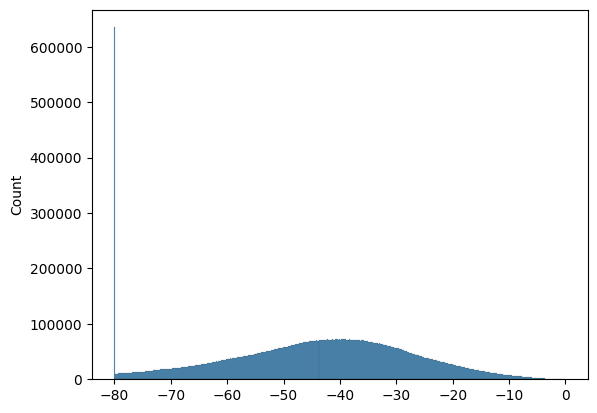

In [ ]:
print("max value: ", np.max(x_train_mfcc_general))
print("min value: ", np.min(x_train_mfcc_general))
print("mean value: ", np.mean(x_train_mfcc_general))
print("std value: ", np.std(x_train_mfcc_general))
sns.histplot(x_train_mfcc_general[:100,...].flatten())
plt.show()

Habiendo detectado que el mínimo es -80 y el máximo es un valor positivo muy cercano a 0 (por lo que se asume 0), se aplica una normalización min-max sobre el conjunto de features de training, validación y testing. No se lleva a cabo una normalización por desviación ni media ya que como bien se dijo antes, la media y la desviación ya se encuentran en valores típicos para el problema. Entonces, con una normalizacion min-max basta y aparte se mantiene la relación relativa de energía entre coeficientes, siendo que no hay outliers grandes ni desviaciones extremas que hagan que una normalización por media y desviación aporte mucho (eso se puede ver claramente en la curva para las primeras 100 muestras de la que se hablaba recién).

Por otra parte, se recorta ya de entrada la dimensión de pasos de tiempo que era de 1290 a 500, para los 3 conjuntos. Esto es porque básicamente con este cambio no hay problemas con el hardware que provee Colab. Se probó incluso con dividir las muestras en 3, donde esta dimensión queda de 430, para así incluir los datos para todos los pasos de tiempo (obviamente no tiene el mismo rendimiento por partes que si fuera todo junto, pero es una alternativa). Sin embargo, es muy costoso durante el entrenamiento ya que sigue siendo necesario más RAM. Se intentó incluso usar un batch size de 8 al entrenar los modelos (la cuarta parte del que se venía usando) y aun así daba problemas, por lo que se usó directamente el recorte de 500 tal cual el que brindaba el ejemplo proporcionado por la cátedra.

In [5]:
x_train_mfcc_complete, x_val_mfcc_complete, y_train_mfcc, y_val_mfcc = train_test_split(x_train_mfcc_general, y_train_mfcc_general, test_size=0.2, random_state=42, stratify=y_train_mfcc_general)
del x_train_mfcc_general
del y_train_mfcc_general

x_train_mfcc = x_train_mfcc_complete[:, :, 500:1000]
del x_train_mfcc_complete
x_val_mfcc   = x_val_mfcc_complete[:, :, 500:1000]
del x_val_mfcc_complete
x_test_mfcc  = x_test_mfcc_general[:, :, 500:1000]
del x_test_mfcc_general

x_train_mfcc = np.expand_dims(x_train_mfcc, axis=-1)
x_val_mfcc   = np.expand_dims(x_val_mfcc, axis=-1)
x_test_mfcc  = np.expand_dims(x_test_mfcc, axis=-1)

x_train_mfcc += 80
x_train_mfcc /= 80

x_val_mfcc += 80
x_val_mfcc /= 80

x_test_mfcc += 80
x_test_mfcc /= 80

y_train_mfcc = np.asarray(y_train_mfcc)
y_val_mfcc = np.asarray(y_val_mfcc)

print("x_train_mfcc: ", x_train_mfcc.shape)
print("x_val_mmfcc: ", x_val_mfcc.shape)
print("y_train_mfcc: ", y_train_mfcc.shape)
print("y_val_mfcc: ", y_val_mfcc.shape)
print("x_test_mfcc", x_test_mfcc.shape)


x_train_mfcc:  (5116, 128, 500, 1)
x_val_mmfcc:  (1279, 128, 500, 1)
y_train_mfcc:  (5116,)
y_val_mfcc:  (1279,)
x_test_mfcc (1599, 128, 500, 1)


Se puede observar para el mismo conjunto de muestras de la primera curva cómo ahora los datos están normalizados entre 0 y 1.

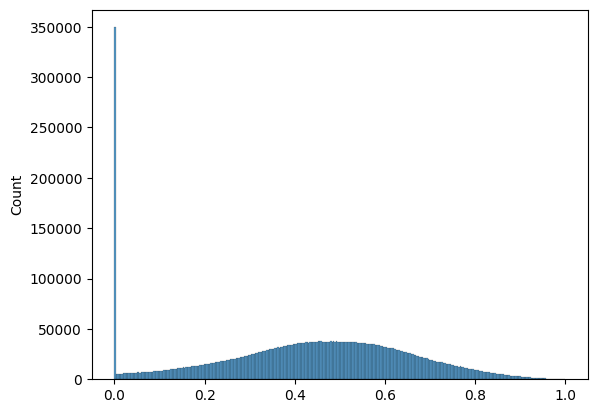

In [ ]:
sns.histplot(x_train_mfcc[:100,...].flatten())
plt.show()

La arquitectura para el entrenamiento con datos de MFCC consta de:

- _Capa de entrada:_ Las muestras que se reciben son tensores de forma (128, 500, 1), donde la primera representa las bandas de frecuencia, la segunda corresponde a los pasos de tiempo (recordar que se recortó de 1290 a 500 para no tener problemas con el hardware disponible), y la tercera es como una especie de escala de grises, tratando la entrada como si fuera una imagen monocromática. En otras palabras, es una imagen que representa cómo evoluciona el espectro del audio en el tiempo.

- _Bloque convolucional 1:_ Compuesto por 2 capas de convolución Conv2D con 32 filtros cada una, de kernel de 3x3. Posee un batch normalization para evitar que se vuelva inestable el entrenamiento y acelerar la convergencia, una activación ReLU (para introducir no linealidad y que se puedan aprender características complejas de la "imagen"), MaxPooling2D para reducir la dimensionalidad del mapa de características para el siguiente bloque, y un dropout no muy alto (0,25), para reducir las posibilidades de overfitting. No es muy alto el dropout justamente porque es un bloque con capas de pocos filtros, entonces no se está ante tanto riesgo de overfitting. Lógicamente, es un bloque que detecta patrones muy básicos del espectrograma, como lo pueden ser transiciones rápidas en algunas frecuencias o cambios cortos en el tiempo.

- _Bloque convolucional 2:_ Es igual al anterior solo que con el doble de filtros por capa (para aprender patrones más complejos), y un dropout un poco más alto (0,3), ya que al duplicar el número de filtros se está ante más riesgo de overfitting.

- _Bloque convolucional 3:_ Tiene la particularidad de que posee convoluciones con filtros de 3x3 y de 1x1. Por un lado, las de 1x1 apuntan más a lo que es un ajuste fino, recombinando la información entre mapas de activación sin mirar la vecindad espacial. En cambio la de 3x3 que está en el medio es para patrones más amplios. Como se puede ver, la primera capa es de 64 filtros (igual que para el bloque previo), y las últimas 2 son del doble, o sea 128. En lo que respecta a función de activación y batch normalization es igual que las anteriores, y al ser un bloque más amplio que captura características muy complejas, el dropout se vuelve a incrementar (0,4).

- _Bloque convolucional 4:_ Este bloque tiene una sola capa convolucional de 256 filtros, donde el modelo se enfoca ya en representaciones muy abstractas y de alto nivel, combinando regiones amplias del espectrograma. A diferencia de la primera capa donde se trataba de patrones muy básicos, acá puede aprenderse algo como una presencia de percusión constante. En esta ocasión se mantuvo el dropout, dado que ya venía de un valor alto (0,4).

- _Bloque de capa de aplanamiento + capas densas:_ Primero que nada hay una capa de flatten, que aplana el mapa de características en un vector largo para que este pueda entrar luego a una capa densa de 256 neuronas, y a esta le sigue una de 128 neuronas. Ambas poseen batch normalization y funciones de activación ReLU, y la primera tiene un dropout incluso más alto que el de antes (0,5), ya que son tantas las conexiones que esta capa puede tener que es muy propensa a overfitting (como se ve en la tabla, cuenta con 16.253.184 parametros). En cambio, la segunda al ser más chica tiene un dropout más bajo, concretamente de 0,3. Básicamente estas capas son como un clasificador final que combina las representaciones que se extrajeron durante las convoluciones.

- _Capa de salida:_ Posee 8 neuronas, y cada una de ellas representa una de las posibles clases a la que puede estar asociada la entrada (ya que son los 8 géneros musicales en los que se busca clasificar). En esta ocasión la activación es Softmax, porque al tratarse de un problema de clasificación multiclase, esta convierte los valores resultantes de la capa de salida en cuestión en probabilidades positivas que entre todas suman 1 (ya que cada una representa la posibilidad de que la entrada pertenezca a una clase determinada, o sea un género musical). No se usa BatchNorm ni Dropout aquí, porque la salida debe ser limpia y estable.

La elección de esta arquitectura para los entrenamientos con el MFCC se debe a que esta representación posee una estructura bidimensional (tiempo y frecuencia), que simula una imagen. Por ende, las capas convolucionales permiten captar patrones locales en ambos ejes, mientras que el pooling y el dropout reducen la dimensionalidad y previenen el sobreajuste. Finalmente, las capas densas integran la información extraída para la clasificación final.

In [6]:
input_shape = (128, 500, 1)
num_classes = 8

model = keras.Sequential([
    layers.Input(shape=input_shape),

    layers.Conv2D(32, 3, padding='same'), layers.BatchNormalization(), layers.ReLU(),
    layers.Conv2D(32, 3, padding='same'), layers.BatchNormalization(), layers.ReLU(),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Conv2D(64, 3, padding='same'), layers.BatchNormalization(), layers.ReLU(),
    layers.Conv2D(64, 3, padding='same'), layers.BatchNormalization(), layers.ReLU(),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),

    layers.Conv2D(64, 1, padding='same'), layers.BatchNormalization(), layers.ReLU(),
    layers.Conv2D(128, 3, padding='same'), layers.BatchNormalization(), layers.ReLU(),
    layers.Conv2D(128, 1, padding='same'), layers.BatchNormalization(), layers.ReLU(),
    layers.MaxPooling2D(),
    layers.Dropout(0.4),

    layers.Conv2D(256, 3, padding='same'), layers.BatchNormalization(), layers.ReLU(),
    layers.MaxPooling2D(),
    layers.Dropout(0.4),


    layers.Flatten(),
    layers.Dense(256), layers.BatchNormalization(), layers.ReLU(),
    layers.Dropout(0.5),
    layers.Dense(128), layers.BatchNormalization(), layers.ReLU(),
    layers.Dropout(0.3),

    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['sparse_categorical_accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 500, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 500, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 128, 500, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 500, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 500, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 128, 500, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 250, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 250, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 250, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 250, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 64, 250, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 250, 64)    │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 250, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 64, 250, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 125, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 125, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 125, 64)    │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 125, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 32, 125, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 125, 128)   │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 125, 128)   │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 32, 125, 128)   │             

 Total params: 16,746,408 (63.88 MB)

 Trainable params: 16,744,104 (63.87 MB)

 Non-trainable params: 2,304 (9.00 KB)

- Se usa un optimizador AdamW, el cual es una variante a Adam con decaimiento de peso que es buena para evitar el overfitting. El decaimiento del peso es de 1E-3.

- La función de pérdida es sparse_categorical_cross_entropy, conveniente porque las etiquetas son enteros en vez de vectores one-hot.

- Son 75 épocas máximas de entrenamiento pero puede haber menos ya que se usa early stopping para evitar entrenar de más y caer en overfitting. El early stopping usa como referencia de monitoreo la pérdida en validación, con una paciencia de 15 épocas, lo que significa que si dicha pérdida no tiene una mejora en 15 épocas, detiene el entrenamiento. Además, debido al restore_best_weights se queda con los parámetros de la mejor época (o sea 15 por detrás de la última si hubo efectivamente un early stopping), en lugar de los de la última.

- La tasa de aprendizaje comienza en 1E-3 y se ajusta dinámicamente en base al scheduler de ReduceLROnPlateau. Básicamente este sigue una política en la que se comienza con un learning rate más alto (justamente 1E-3) y lo reduce de manera automática en un factor (en este caso 0,1), cuando la referencia de monitoreo (pérdida de validación) no mejora durante un número de épocas determinado (paciencia de 5). El mínimo definido para la tasa es 1E-4 (valor con el cual se busca refinar más), ya que debajo de este ya es muy bajo y además son valores típicos en los que funcionan bien las redes neuronales.

- Se utiliza un batch size de 32, dado que es un equilibrio entre velocidad de cómputo y estabilidad (para los datos de entrada no hay problemas con este tamaño de lote en cuanto a la VRAM de la placa T4 que asigna Colab).


In [ ]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.1,
    patience=5,
    min_lr=0.0001
)

history = model.fit(
    x_train_mfcc,
    y_train_mfcc,
    epochs=75,
    validation_data=(x_val_mfcc, y_val_mfcc),
    batch_size=32,
    callbacks=[early_stopping, reduce_lr]
)

model.save(model_mfcc_complete_path)
print(f"Modelo entrenado y guardado en '{model_mfcc_complete_path}'")

Epoch 1/75
160/160 ━━━━━━━━━━━━━━━━━━━━ 100s 402ms/step - loss: 2.1501 - sparse_categorical_accuracy: 0.2392 - val_loss: 4.7623 - val_sparse_categorical_accuracy: 0.1290 - learning_rate: 0.0010
Epoch 2/75
160/160 ━━━━━━━━━━━━━━━━━━━━ 32s 203ms/step - loss: 1.7278 - sparse_categorical_accuracy: 0.3863 - val_loss: 3.9332 - val_sparse_categorical_accuracy: 0.1540 - learning_rate: 0.0010
Epoch 3/75
160/160 ━━━━━━━━━━━━━━━━━━━━ 32s 199ms/step - loss: 1.6126 - sparse_categorical_accuracy: 0.4061 - val_loss: 3.4930 - val_sparse_categorical_accuracy: 0.1665 - learning_rate: 0.0010
Epoch 4/75
160/160 ━━━━━━━━━━━━━━━━━━━━ 42s 203ms/step - loss: 1.5262 - sparse_categorical_accuracy: 0.4654 - val_loss: 1.8046 - val_sparse_categorical_accuracy: 0.3401 - learning_rate: 0.0010
Epoch 5/75
160/160 ━━━━━━━━━━━━━━━━━━━━ 32s 198ms/step - loss: 1.4404 - sparse_categorical_accuracy: 0.4869 - val_loss: 1.9226 - val_sparse_categorical_accuracy: 0.3448 - learning_rate: 0.0010
Epoch 6/75
160/160 ━━━━━━━━━━━━━━━

Modelo entrenado y guardado en '/content/drive/My Drive/DUIA-Redes-Neuronales/DatasetMusic/sample/model5.h5'


In [ ]:
del model

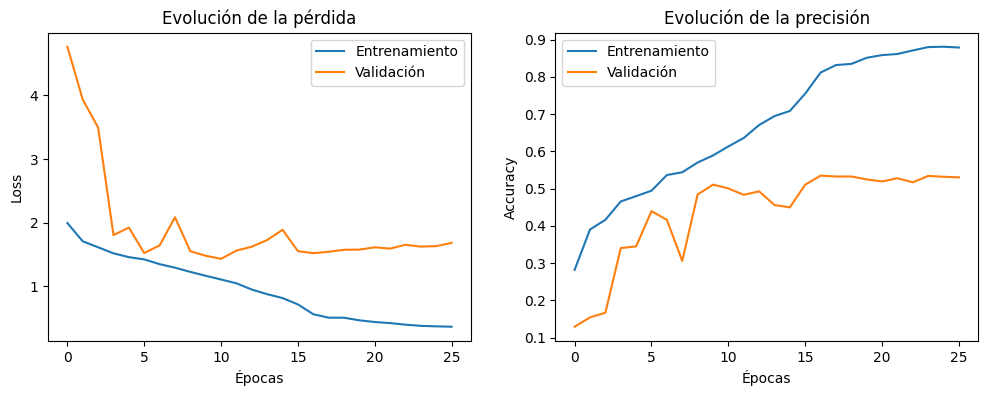

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Evolución de la pérdida')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['sparse_categorical_accuracy'], label='Entrenamiento')
plt.plot(history.history['val_sparse_categorical_accuracy'], label='Validación')
plt.title('Evolución de la precisión')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

Como se puede ver, en este caso el entrenamiento se detuvo en la época número 26, ya que desde la pérdida en validación más baja registrada pasaron 15 épocas (época 11 con pérdida de validación de 1,4322). Por lo tanto, los parámetros del modelo que son almacenados son los de la época 11 (se guardan los de la mejor por la configuración del early stopping ya mencionada), para la cual además se registró un val_sparse_categorical_accuracy de 0,5004.

Es evidente al ver la evolución de las funciones de costo que había llegado un punto en el cual la pérdida de validación comenzaba a crecer prácticamente de forma lineal mientras la de entrenamiento decrecía considerablemente, lo que quiere decir que probablemente empezó a caer en overfitting, lo cual fue evitado a través del early stopping. Al mismo tiempo, el accuracy de entrenamiento subía a valores muy altos pero el de validación ya no se incrementaba más y de hecho parecía empezar a decrecer levemente de forma lineal.

Si bien los datos de testing establecidos para el trabajo no poseen etiquetas y por ende no se pueden establecer métricas con ellas, sí se puede hacer en base a los datos de validación un análisis de los resultados para el estado final del modelo. Está claro para este caso que las precisiones por clase varían demasiado, desde 0,34 para el género 6 (peor) hasta 0,84 para el género 3 (mejor).

Por otra parte, el recall (que mide para todas las muestras de una clase en particular, cuántas se predijeron realmente como pertenecientes a esa clase), tuvo un comportamiento que no varió tanto. Para las clases 0, 1, 2, 3, 4 y 7 adoptó valores comprendidos entre 0,52 y 0,57. En cambio, para la clase 5 tuvo un valor de 0,44, y ya para el género 6 fue muy malo, con 0,23.

Mirando el F-score (que es la media armónica entre precisión y recall), el mejor resultado es para el género 3 (0,68), ya que tiene el valor más alto de precisión y comparte el valor más alto de recall con otras 2 clases. De todas formas, si se compara su accuracy con su recall, es mucho más alto el accuracy, lo cual sugiere que para dicho género el modelo deja pasar probablemente bastantes casos positivos, pero que cuando predice que se trata de ese género muy rara vez se equivoca. Volviendo a lo que respecta al F-score y concretamente al valor más bajo, como era de esperarse lo tiene la clase 6, con tan solo 0,27 y esto resulta de que tiene tanto el accuracy como el recall más bajos.

Validation Loss: 1.4322
Validation Accuracy: 0.5004
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step

Classification report (validation):
              precision    recall  f1-score   support

           0       0.49      0.56      0.52       160
           1       0.37      0.52      0.43       160
           2       0.51      0.57      0.54       160
           3       0.84      0.57      0.68       159
           4       0.40      0.57      0.47       160
           5       0.70      0.44      0.54       160
           6       0.34      0.23      0.27       160
           7       0.59      0.54      0.56       160

    accuracy                           0.50      1279
   macro avg       0.53      0.50      0.50      1279
weighted avg       0.53      0.50      0.50      1279


Confusion matrix (validation):




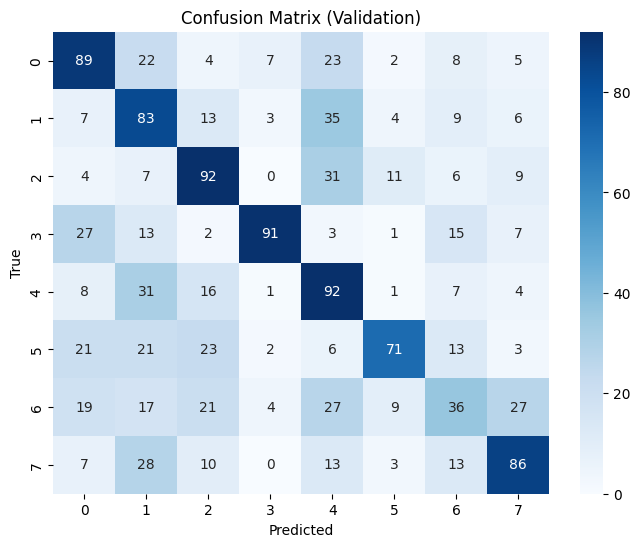

In [ ]:
model = keras.models.load_model(model_mfcc_complete_path)

val_loss, val_acc = model.evaluate(x_val_mfcc, y_val_mfcc, verbose=0)
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")

y_val_pred = np.argmax(model.predict(x_val_mfcc), axis=-1)

print("\nClassification report (validation):")
print(classification_report(y_val_mfcc, y_val_pred))

cm = confusion_matrix(y_val_mfcc, y_val_pred)

print("\nConfusion matrix (validation):")
cm_df = pd.DataFrame(cm)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Validation)")
print("\n")
plt.show()

Algunas predicciones sobre el conjunto de testing.

In [7]:
del model
model = keras.models.load_model(model_mfcc_complete_path)
y_pred = np.argmax(model.predict(x_test_mfcc), axis=-1)
prediction = test['track_id'].to_frame()
prediction['genre'] = y_pred
#Descomentar para guardar las predicciones
#prediction.to_csv(model_path + 'sample_predictions.csv', index=False)
prediction.head()

50/50 ━━━━━━━━━━━━━━━━━━━━ 187s 4s/step


,track_id,genre
0,126557,4
1,89376,4
2,48440,1
3,140933,0
4,12352,2


# Entrenamientos con las features extra

Se define nombre de modelo basado en features extra a entrenar/cargar.

In [ ]:
model_extraf_name = "model3_ft_extras.h5"
model_extraf_complete_path = model_path + model_extraf_name

Se obtienen los dataframes que contienen las muestras de training y testing, haciendo un join por track_id con los dataframes de train y testing generales que se obtuvieron al principio.

In [ ]:
extra_features = pd.read_csv(data_path + 'extra_features.csv')

train_extra_features = train.join(extra_features.set_index('track_id'), on='track_id')
test_extra_features = test.join(extra_features.set_index('track_id'), on='track_id')

print("train_extra_features shape: ", train_extra_features.shape)
print("test_extra_features shape: ", test_extra_features.shape)
print("extra features: ", train_extra_features.drop(['track_id', 'genre'], axis=1).columns.tolist())
print("examples from train extra features dataset:")
train_extra_features.head()

train_extra_features shape:  (6395, 520)
test_extra_features shape:  (1599, 519)
extra features:  ["('chroma_cens', 'kurtosis', '01')", "('chroma_cens', 'kurtosis', '02')", "('chroma_cens', 'kurtosis', '03')", "('chroma_cens', 'kurtosis', '04')", "('chroma_cens', 'kurtosis', '05')", "('chroma_cens', 'kurtosis', '06')", "('chroma_cens', 'kurtosis', '07')", "('chroma_cens', 'kurtosis', '08')", "('chroma_cens', 'kurtosis', '09')", "('chroma_cens', 'kurtosis', '10')", "('chroma_cens', 'kurtosis', '11')", "('chroma_cens', 'kurtosis', '12')", "('chroma_cens', 'max', '01')", "('chroma_cens', 'max', '02')", "('chroma_cens', 'max', '03')", "('chroma_cens', 'max', '04')", "('chroma_cens', 'max', '05')", "('chroma_cens', 'max', '06')", "('chroma_cens', 'max', '07')", "('chroma_cens', 'max', '08')", "('chroma_cens', 'max', '09')", "('chroma_cens', 'max', '10')", "('chroma_cens', 'max', '11')", "('chroma_cens', 'max', '12')", "('chroma_cens', 'mean', '01')", "('chroma_cens', 'mean', '02')", "('chro

,track_id,genre,"('chroma_cens', 'kurtosis', '01')","('chroma_cens', 'kurtosis', '02')","('chroma_cens', 'kurtosis', '03')","('chroma_cens', 'kurtosis', '04')","('chroma_cens', 'kurtosis', '05')","('chroma_cens', 'kurtosis', '06')","('chroma_cens', 'kurtosis', '07')","('chroma_cens', 'kurtosis', '08')",...,"('tonnetz', 'std', '04')","('tonnetz', 'std', '05')","('tonnetz', 'std', '06')","('zcr', 'kurtosis', '01')","('zcr', 'max', '01')","('zcr', 'mean', '01')","('zcr', 'median', '01')","('zcr', 'min', '01')","('zcr', 'skew', '01')","('zcr', 'std', '01')"
0,118063,4,-0.866501,-0.596604,-0.879332,-0.547012,-0.936824,-0.611808,-0.815056,-0.654114,...,0.142223,0.022591,0.026227,91.723145,0.309082,0.018832,0.015137,0.001465,8.626294,0.022286
1,138216,3,5.963853,3.091741,2.475644,1.617254,0.658485,0.248763,-0.617282,3.949076,...,0.100715,0.020780,0.021194,14.844618,0.545898,0.038871,0.027344,0.002441,2.841014,0.038048
2,48864,1,1.470971,0.931905,0.958449,1.049292,0.686017,0.823663,0.665622,0.403858,...,0.050390,0.017129,0.017032,12.775474,0.291992,0.034002,0.026855,0.000000,3.050526,0.026753
3,72070,0,0.302299,-1.077104,-0.722465,-0.474958,-0.623521,-0.988215,-1.234258,-0.332871,...,0.060895,0.025342,0.019848,19.352873,0.469238,0.053265,0.042969,0.000000,3.698871,0.050437
4,121452,0,0.647318,2.018942,-0.343311,-0.921623,0.501049,-0.164405,-0.176288,1.043031,...,0.085316,0.021680,0.021217,120.288506,0.840820,0.038165,0.026855,0.001953,9.658852,0.055946


Se hace un splitting en training y validación de las muestras de training generales. Para las features finales de ambos conjuntos se elimina el track_id (porque un id no representa información relevante) y el género, ya que justamente es el target a predecir. Para los conjuntos de targets de cada uno (y), lógicamente se queda solo con el género.

El conjunto original de training entonces se divide en un 80% para entrenamiento y un 20% para validación.

In [ ]:
x_train_extra, x_val_extra, y_train_extra, y_val_extra = train_test_split(
    train_extra_features.drop(['track_id', 'genre'], axis=1).values,
    train_extra_features['genre'].values,
    test_size=0.2,
    random_state=42,
    stratify=train_extra_features['genre'].values
)

x_test_extra = test_extra_features.drop('track_id', axis=1).values

print("x_train_extra shape:", x_train_extra.shape)
print("x_val_extra shape:", x_val_extra.shape)
print("y_train_extra shape:", y_train_extra.shape)
print("y_val_extra shape:", y_val_extra.shape)
print("x_test_extra shape:", x_test_extra.shape)

x_train_extra shape: (5116, 518)
x_val_extra shape: (1279, 518)
y_train_extra shape: (5116,)
y_val_extra shape: (1279,)
x_test_extra shape: (1599, 518)


Se aplica StandardScaler, que transforma cada feature para que tenga media cero y desviación estándar uno. Esto ayuda a la red neuronal a funcionar mejor porque las entradas están centradas y tienen escalas similares, evitando que algunas features dominen sobre otras por su magnitud. Es fundamental además antes de aplicar PCA.

Se usa PCA para reducir la dimensionalidad de los datos, buscando una combinación lineal de las features originales que capture la mayor cantidad de varianza posible. Se configuró con n_componentes=0,95, para conservar el 95% de la varianza total, eliminando información redundante o poco relevante. Las ventajas son que acelera el entrenamiento y ayuda a reducir el riesgo de overfitting (porque el espacio de características es más compacto y representativo). Esto resulta en exactamente 200 columnas (reducción de 518 a 200).

In [ ]:
scaler = StandardScaler()
x_train_extra = scaler.fit_transform(x_train_extra)
x_val_extra = scaler.transform(x_val_extra)
x_test_extra = scaler.transform(x_test_extra)

pca = PCA(n_components=0.95, random_state=42)
x_train_extra = pca.fit_transform(x_train_extra)
x_val_extra = pca.transform(x_val_extra)
x_test_extra = pca.transform(x_test_extra)

print("x_train_pca shape:", x_train_extra.shape)
print("x_val_pca shape:", x_val_extra.shape)
print("x_test_pca shape:", x_test_extra.shape)

x_train_pca shape: (5116, 200)
x_val_pca shape: (1279, 200)
x_test_pca shape: (1599, 200)


La arquitectura para el entrenamiento con features extra consta de:

- _Capa de entrada:_ Las muestras que recibe son vectores de 200 dimensiones, que básicamente son las que quedaron tras la reducción por PCA, luego de la normalización por escalado.

- _Bloque denso 1:_ Compuesto por 1024 neuronas, es una capa grande en la que el modelo inicialmente captura relaciones complejas entre las features (pero más globales). Posee un batch normalization para evitar que se vuelva inestable el entrenamiento y acelerar la convergencia, una activación ReLU (para introducir no linealidad y que se puedan aprender combinaciones complejas) y un dropout relativamente alto (0,4) para reducir las posibilidades de overfitting.

- _Bloque denso 2:_ Compuesto por 512 neuronas (la mitad que anteriormente). Se filtran representaciones más compactas. Mismo dropout de antes (0,4) ya que sigue siendo una capa relativamente grande. Por el mismo motivo que antes se aplica batch normalization y una activación ReLU.

- _Bloque denso 3:_ Compuesto por 128 neuronas (1/4 de la anterior). Ya aquí se aprenden representaciones intermedias bastante pequeñas, lo que permite al modelo generalizar detalles específicos. El dropout es un poco más bajo, específicamente de 0,3, ya que al trabajar con representaciones muy concretas que ya pasaron por capas mucho más grandes (y con dropouts altos), es mucho menor el riesgo de overfitting. Por el mismo motivo que antes se aplica batch normalization y una activación ReLU.

- _Bloque denso 4:_ Compuesto por 256 neuronas (el doble que la del 3). Básicamente, se expande después de haber comprimido para facilitar la separación de clases en el espacio de características final. El dropout es aún más bajo ya que la representación es mucho más refinada en este punto. Por el mismo motivo que antes, se aplica batch normalization y una activación ReLU.

- _Capa de salida:_ Posee 8 neuronas, y cada una de ellas representa una de las posibles clases a la que puede estar asociada la entrada (ya que son los 8 géneros musicales en los que se busca clasificar). En esta ocasión la activación es Softmax, porque al tratarse de un problema de clasificación multiclase, esta convierte los valores resultantes de la capa de salida en cuestión en probabilidades positivas que entre todas suman 1 (ya que cada una representa la posibilidad de que la entrada pertenezca a una clase determinada, o sea un género musical). No se usa BatchNorm ni Dropout aquí, porque la salida debe ser limpia y estable.

La elección del uso de capas densas en vez de capas convolucionales para los modelos entrenados con las features extra es que justamente estas consisten de vectores de entrada con 200 características numéricas (reducción de las 518 originales), donde no hay una estructura espacial ni temporal (para el MFCC en cambio sí hay un alto y un ancho porque se representa como una imagen). Entonces, las capas densas son ideales porque aprenden los pesos que tiene que darle a cada columna o feature para predecir la clase.

In [ ]:
input_shape = (200,)
num_classes = 8

model = keras.Sequential([
    layers.Input(shape=input_shape),

    layers.Dense(1024), layers.BatchNormalization(), layers.ReLU(),
    layers.Dropout(0.4),

      layers.Dense(512), layers.BatchNormalization(), layers.ReLU(),
    layers.Dropout(0.4),

    layers.Dense(128), layers.BatchNormalization(), layers.ReLU(),
    layers.Dropout(0.3),

    layers.Dense(256), layers.BatchNormalization(), layers.ReLU(),
    layers.Dropout(0.2),

    layers.Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer=AdamW(learning_rate=1e-4, weight_decay=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["sparse_categorical_accuracy"]
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1024)           │       205,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 839,048 (3.20 MB)

 Trainable params: 835,208 (3.19 MB)

 Non-trainable params: 3,840 (15.00 KB)

- Se usa un optimizador AdamW, el cual es una variante de Adam con decaimiento de peso, que es buena para evitar el overfitting. El decaimiento del peso es de 1E-4.

- La función de pérdida es sparse_categorical_crossentropy, conveniente porque las etiquetas son enteros en vez de vectores one-hot.

- Son 200 épocas máximas de entrenamiento, pero puede haber menos ya que se usa early stopping para evitar entrenar de más y caer en overfitting. El early stopping usa como referencia de monitoreo la pérdida en validación, con una paciencia de 40 épocas, lo que significa que si dicha pérdida no tiene una mejora en 40 épocas, detiene el entrenamiento. Además, debido al restore_best_weights, se queda con los parámetros de la mejor época (o sea 40 por detrás de la última si hubo efectivamente un early stopping), en lugar de los de la última.

- La tasa de aprendizaje comienza en 1E-4 y se ajusta dinámicamente en base al scheduler de ReduceLROnPlateau. Básicamente, este sigue una política en la que se comienza con un learning rate más alto (justamente 1E-4) y lo reduce de manera automática en un factor (en este caso 0,1), cuando la referencia de monitoreo (pérdida de validación) no mejora durante un número de épocas determinado (paciencia de 5). El mínimo definido para la tasa es 1E-5 (valor con el cual se busca refinar más), ya que debajo de este ya es muy bajo y además son valores típicos en los que funcionan bien las redes neuronales.

- Se utiliza un batch size de 32, dado que es un equilibrio entre velocidad de cómputo y estabilidad (para los datos de entrada no hay problemas con este tamaño de lote en cuanto a la VRAM de la placa T4 que asigna Colab).

In [ ]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=40,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.1,
    patience=5,
    min_lr=0.00001
)

history = model.fit(
    x_train_extra,
    y_train_extra,
    epochs=200,
    validation_data=(x_val_extra, y_val_extra),
    batch_size=32,
    callbacks=[early_stopping, reduce_lr]
)

model.save(model_extraf_complete_path)
print(f"Modelo entrenado y guardado en '{model_extraf_complete_path}'")

Epoch 1/200
160/160 ━━━━━━━━━━━━━━━━━━━━ 16s 38ms/step - loss: 2.3610 - sparse_categorical_accuracy: 0.1656 - val_loss: 1.8031 - val_sparse_categorical_accuracy: 0.3831 - learning_rate: 1.0000e-04
Epoch 2/200
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2.0227 - sparse_categorical_accuracy: 0.2539 - val_loss: 1.6306 - val_sparse_categorical_accuracy: 0.4332 - learning_rate: 1.0000e-04
Epoch 3/200
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.8171 - sparse_categorical_accuracy: 0.3300 - val_loss: 1.5424 - val_sparse_categorical_accuracy: 0.4676 - learning_rate: 1.0000e-04
Epoch 4/200
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.7389 - sparse_categorical_accuracy: 0.3529 - val_loss: 1.4800 - val_sparse_categorical_accuracy: 0.4840 - learning_rate: 1.0000e-04
Epoch 5/200
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.6803 - sparse_categorical_accuracy: 0.3927 - val_loss: 1.4293 - val_sparse_categorical_accuracy: 0.4973 - learning_rate: 1.0000e-04
Epoch 6/200
160/160 ━━━

Modelo entrenado y guardado en '/content/drive/My Drive/DUIA-Redes-Neuronales/DatasetMusic/sample/model3_ft_extras.h5'


In [ ]:
del model

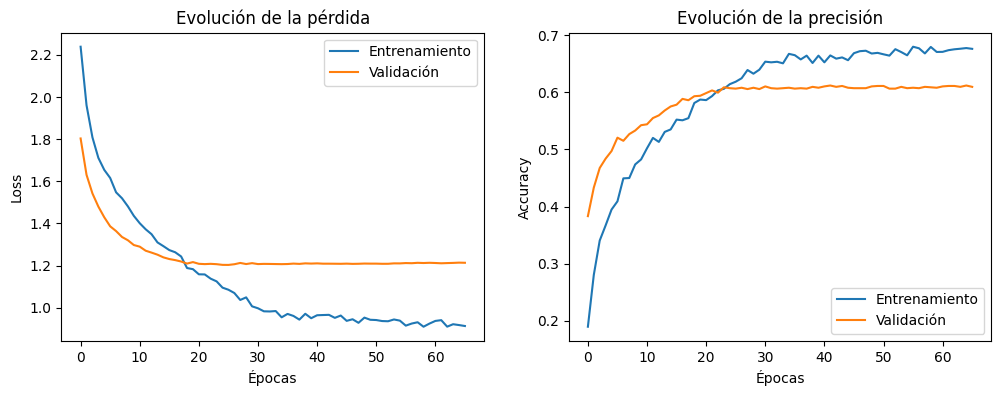

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Evolución de la pérdida')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['sparse_categorical_accuracy'], label='Entrenamiento')
plt.plot(history.history['val_sparse_categorical_accuracy'], label='Validación')
plt.title('Evolución de la precisión')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

Como se puede ver, en este caso el entrenamiento se detuvo en la época número 66, ya que desde la pérdida en validación más baja registrada pasaron 40 épocas (época 26 con pérdida de validación de 1,2034). Por lo tanto, los parámetros del modelo que son almacenados son los de la época 26 (se guardan los de la mejor por la configuración del early stopping ya mencionada), para la cual además se registró un val_sparse_categorical_accuracy de 0,6067.

Es evidente al ver la evolución de las funciones de costo que había llegado un punto en el cual la pérdida de validación se mantenía prácticamente constante, lo que quiere decir que probablemente alcanzó un mínimo local o global del que no puede mejorar más, ya sea por una limitación de los datos de entrenamiento o por otro motivo. Si bien la tasa de aprendizaje no es alta, tampoco es tan baja y de hecho el propio scheduler la reduce al 10% cuando es necesario, por lo que seguramente no esté relacionado al learning rate ese aplanamiento de la pérdida de validación. En consecuencia, si bien la pérdida de entrenamiento seguía bajando, al no bajar la de validación probablemente se estaba empezando a caer en un overfitting, lo cual fue evitado a través del early stopping. A la par y de manera lógica, el accuracy de entrenamiento subía pero el de validación ya no se incrementaba más, básicamente por ese mismo motivo.

Si bien los datos de testing establecidos para el trabajo no poseen etiquetas y por ende no se pueden establecer métricas con ellas, sí se puede hacer en base a los datos de validación un análisis de los resultados para el estado final del modelo. Como se puede ver, la precisión para la mayoría de las clases estuvo entre 0,59 y 0,69. Sin embargo, para la clase 6 fue mucho menor (0,38), y como evidencia la matriz de confusión, los errores cuando la clase 6 era la clase real se distribuyeron relativamente similar entre las demás clases predichas (es decir, cuando el género real es el 6 no es que se confunde casi siempre con otro género en particular, sino que está bastante disperso), lo que sugiere que la incertidumbre para ese género es muy alta. Si a esto se le suma que la cantidad de ejemplos para todos los géneros es casi la misma (160 para todos excepto 159 para uno, de acuerdo al support), está claro que la división de validación es muy justa y confirma aún más la debilidad del modelo para predecir la clase 6.

Por otra parte, el recall (que mide para todas las muestras de una clase en particular, cuántas se predijeron realmente como pertenecientes a esa clase) para los géneros 0 y 1 fue considerablemente más bajo que la precisión (lo que sugiere que deja pasar muchos que realmente son de esa clase), mientras que para los demás fue igual o mejor (comparando con el valor de precisión alcanzado para esos casos, se puede decir que es relativamente buena la cantidad de positivos que detecta correctamente, pero a costa de predecir en muchas ocasiones que es esa clase cuando realmente no lo es). Mirando el F-score (que es la media armónica entre precisión y recall), el mejor resultado es para el género 5 (0,70), puesto que tiene uno de los mejores valores de precisión y también de recall, lo que sugiere que es un género para el cual el modelo predice bien los casos positivos, pero a la vez sin incurrir en muchos falsos positivos para dicha clase.

Validation Loss: 1.2034
Validation Accuracy: 0.6067
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step

Classification report (validation):
              precision    recall  f1-score   support

           0       0.65      0.53      0.58       160
           1       0.69      0.36      0.48       160
           2       0.66      0.68      0.67       160
           3       0.59      0.73      0.66       159
           4       0.63      0.69      0.66       160
           5       0.68      0.71      0.70       160
           6       0.38      0.46      0.42       160
           7       0.65      0.70      0.67       160

    accuracy                           0.61      1279
   macro avg       0.62      0.61      0.60      1279
weighted avg       0.62      0.61      0.60      1279


Confusion matrix (validation):




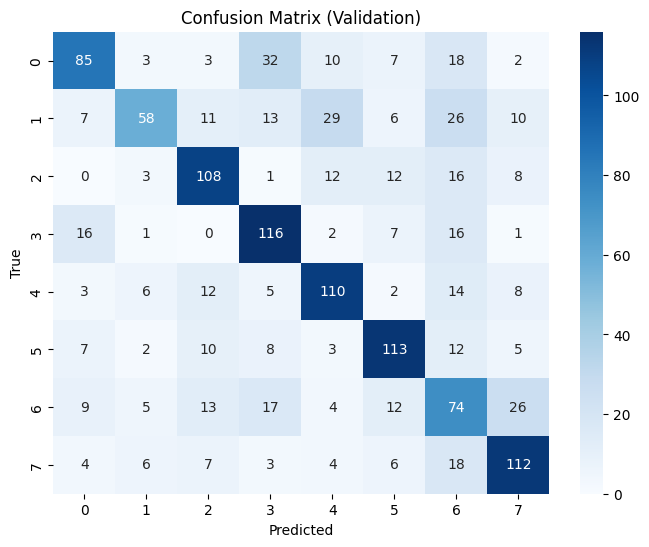

In [ ]:
model = keras.models.load_model(model_extraf_complete_path)

val_loss, val_acc = model.evaluate(x_val_extra, y_val_extra, verbose=0)
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")

y_val_pred = np.argmax(model.predict(x_val_extra), axis=-1)

print("\nClassification report (validation):")
print(classification_report(y_val_extra, y_val_pred))

cm = confusion_matrix(y_val_extra, y_val_pred)

print("\nConfusion matrix (validation):")
cm_df = pd.DataFrame(cm)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Validation)")
print("\n")
plt.show()

Algunas predicciones sobre el conjunto de testing.

In [ ]:
del model
model = keras.models.load_model(model_extraf_complete_path)
y_pred = np.argmax(model.predict(x_test_extra), axis=-1)
prediction = test['track_id'].to_frame()
prediction['genre'] = y_pred
#Descomentar para guardar las predicciones
#prediction.to_csv(model_path + 'sample_predictions.csv', index=False)
prediction.head()

50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


,track_id,genre
0,126557,4
1,89376,2
2,48440,0
3,140933,4
4,12352,6


# Conclusión final

Como conclusión final, se puede decir que el resultado para el mismo conjunto de validación fue mejor utilizando el modelo basado en las features extra que el que recibe como entrada los MFCC. Esto puede deberse a que probablemente el recorte en la dimensión del número de pasos temporales en el MFCC (dadas las limitaciones de hardware) repercute negativamente, ya que se pierde información, mientras que las features extra se utilizan en su totalidad (con una reducción por PCA, pero donde obviamente las nuevas features representan combinación de información de las anteriores). Algo notorio además es el hecho de que tanto para el mejor modelo con los MFCC como para el mejor con las features extra, el género que cuenta con los peores resultados (y por bastante diferencia con las demás clases) es el 6, lo que significa que probablemente sea complejo de generalizar o que los datos presentes no favorecen el aprendizaje de sus características (podría tratarse tranquilamente del recorte hecho en los espectrogramas del MFCC, pero evidentemente no es eso porque con las features extra ocurre lo mismo).